In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Parâmetros do Sistema

In [2]:
# Taxa média de chegadas externas (pacotes/s)
lambda_rate = 5.0

# Taxa média de serviço (pacotes/s)
mu = 10.0

# Probabilidade de sucesso da transmissão
p = 0.8

# Tempo total da simulação
Tsim = 100000
warmup = 1000

# Semente para reprodutibilidade
np.random.seed(12345)

# Estabilidade
if lambda_rate >= mu * p:
  raise ValueError("Sistema instável: λ >= μp")

## Variáveis de Estado

In [3]:
# Relógio da simulação
t = 0.0

# Número de pacotes presentes no sistema
N = 0

# Instante da próxima chegada
next_arrival = np.random.exponential(1/lambda_rate)

# Instante do próximo término de serviço
next_departure = np.inf

## Implementação da Fila

In [4]:
"""
Cada elemento da lista representa um pacote.

Será armazenado:

arrival_time
    instante da entrada mais recente na fila

first_arrival
    instante da primeira chegada ao sistema

retransmissions
    número de retransmissões realizadas
"""
queue = []

## Variáveis Estatísticas

In [5]:
# Instante do evento anterior
last_event_time = 0.0

# Integral de N(t)
area_N = 0.0

# Integral de Q(t)
area_Q = 0.0

# Número total de pacotes concluídos
num_departures = 0

# Soma dos tempos totais no sistema
total_system_time = 0.0

# Soma das retransmissões
total_retransmissions = 0

# Histórico para gráficos
time_history = []
N_history = []

## Loop Principal da Simulação

In [6]:
while t < Tsim:

  # Determinação do próximo evento

  if next_arrival < next_departure:
    event_type = "arrival"
    t_next = next_arrival
  else:
    event_type = "departure"
    t_next = next_departure

  # Atualização das áreas estatísticas

  dt = t_next - last_event_time

  if t > warmup:
    # Integral do número de pacotes no sistema
    area_N += N * dt
    # Integral do tamanho da fila
    area_Q += max(N - 1, 0) * dt

  last_event_time = t_next
  t = t_next

  # Evento de Chegada

  if event_type == "arrival":

    # Um novo pacote entra no sistema
    N += 1

    # Criação da entidade pacote
    packet = {

        # Primeira chegada ao sistema
        "first_arrival": t,

        # Entrada atual na fila
        "arrival_time": t,

        # Número de retransmissões
        "retransmissions": 0
    }

    # Inserção no final da fila
    queue.append(packet)

    # Agenda próxima chegada
    next_arrival = t + np.random.exponential(
        1/lambda_rate
    )

    # Se servidor estiver ocioso,
    # incia atendimento imediatamente
    if N == 1:
      next_departure = t + np.random.exponential(
          1/mu
      )

  # Evento de Saída do Servidor

  else:

    # Remove primeiro elemento da fila (FIFO)
    packet = queue.pop(0)

    # Sorteia sucesso ou falha
    if np.random.rand() < p:

      # Sucesso

      N -= 1

      num_departures += 1

      # Tempo total do pacote no sistema
      total_system_time += (
          t - packet["first_arrival"]
      )

      total_retransmissions += (
          packet["retransmissions"]
      )

    else:

      # Retransmissão

      packet["retransmissions"] += 1

      packet["arrival_time"] = t

      # Retorna ao final da fila
      queue.append(packet)

    # Agenda próximo término de serviço
    if N > 0:

      next_departure = (
          t + np.random.exponential(1/mu)
      )

    else:
      next_departure = np.inf

  # Salva histórico
  time_history.append(t)
  N_history.append(N)


## Métricas Simuladas

In [7]:
tempo_util = Tsim - warmup

# Número médio no sistema
L_sim = area_N / tempo_util

# Número médio na fila
Lq_sim = area_Q / tempo_util

# Tempo médio no sistema
W_sim = total_system_time / num_departures

# Lei de Little
lambda_eff = lambda_rate / p
Wq_sim = Lq_sim / lambda_eff

# Retransmissões médias
R_sim = (
    total_retransmissions / num_departures
)

## Resultados teóricos

In [8]:
rho = lambda_rate/(mu*p)

L_theory = rho/(1-rho)
Lq_theory = rho**2/(1-rho)

W_theory = 1/(mu - lambda_rate/p)
Wq_theory = rho/(mu - lambda_rate/p)

R_theory = (1-p)/p

## Tabela Teoria x Simulação

In [9]:
df = pd.DataFrame({
    "Métrica":[
        "L","Lq","W","Wq","Retransmissões"
    ],
    "Simulação":[
        L_sim,Lq_sim,W_sim,Wq_sim,R_sim
    ],
    "Teoria":[
        L_theory,Lq_theory,W_theory,Wq_theory,R_theory
    ]
})

print(df)

          Métrica  Simulação    Teoria
0               L   1.671376  1.666667
1              Lq   1.046329  1.041667
2               W   0.334220  0.266667
3              Wq   0.167413  0.166667
4  Retransmissões   0.250087  0.250000


## Comparação de Filas

In [10]:
# Comparação entre modelos

rho_mm1 = lambda_rate/mu

L_mm1  = rho_mm1/(1-rho_mm1)

W_mm1 = 1/(mu-lambda_rate)

# M/D/1
L_md1 = rho_mm1 + (rho_mm1**2)/(2*(1-rho_mm1))

W_md1 = L_md1/lambda_rate

# M/E2/1
k = 2

L_me2 = rho_mm1 + ((1+1/k)/2)*(
    rho_mm1**2/(1-rho_mm1)
)

W_me2 = L_me2/lambda_rate

# M/M/1/K

K = 10

pb = ((1-rho_mm1)*(rho_mm1**K))/(
    1-rho_mm1**(K+1)
)
L_mm1k = (
    rho_mm1/(1-rho_mm1)
    - ((K+1)*(rho_mm1**(K+1)))
    /(1-rho_mm1**(K+1))
)
W_mm1k = L_mm1k/(
    lambda_rate*(1-pb)
)

# tabela
comp = pd.DataFrame({
    "Modelo":[
        "M/M/1",
        "M/M/1 Feedback",
        "M/D/1",
        "M/E2/1",
        "M/M/1/K"
    ],

    "L":[
        L_mm1,
        L_theory,
        L_md1,
        L_me2,
        L_mm1k
    ],

    "W":[
        W_mm1,
        W_theory,
        W_md1,
        W_me2,
        W_mm1k
    ]
})

print("\nComparação entre filas")
print(comp)


Comparação entre filas
           Modelo         L         W
0           M/M/1  1.000000  0.200000
1  M/M/1 Feedback  1.666667  0.266667
2           M/D/1  0.750000  0.150000
3          M/E2/1  0.875000  0.175000
4         M/M/1/K  0.994626  0.199022


## Gráfico 1 - Evolução Temporal

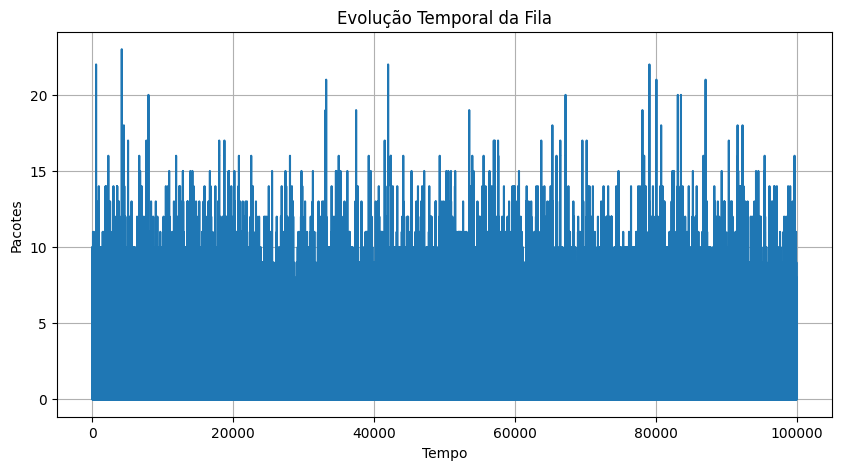

In [11]:
plt.figure(figsize=(10,5))
plt.step(time_history,N_history,where='post')
plt.title("Evolução Temporal da Fila")
plt.xlabel("Tempo")
plt.ylabel("Pacotes")
plt.grid()
plt.show()

## Gráfico 2 - Comparação dos Modelos

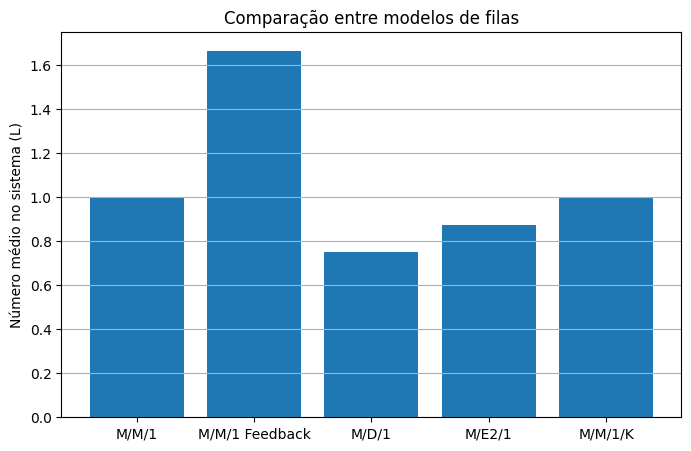

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    comp["Modelo"],
    comp["L"]
)

plt.ylabel("Número médio no sistema (L)")
plt.title("Comparação entre modelos de filas")

plt.grid(axis='y')

plt.show()

## Gráfico 3 - Tempo Médio W

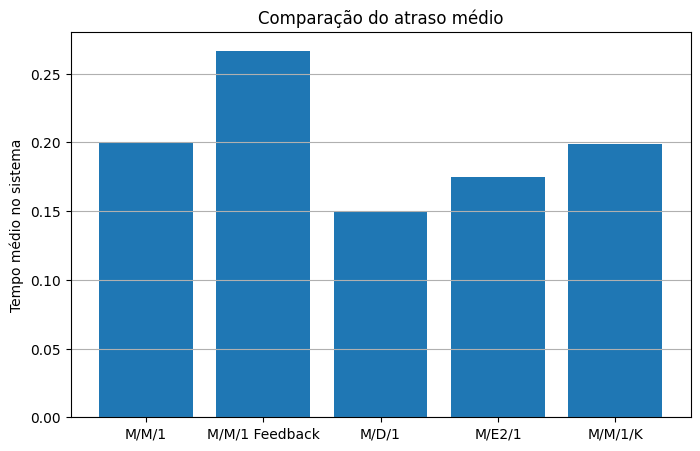

In [13]:
plt.figure(figsize=(8,5))

plt.bar(
    comp["Modelo"],
    comp["W"]
)

plt.ylabel("Tempo médio no sistema")
plt.title("Comparação do atraso médio")

plt.grid(axis='y')

plt.show()

## Gráfico 3 - Efeito da Retransmissão

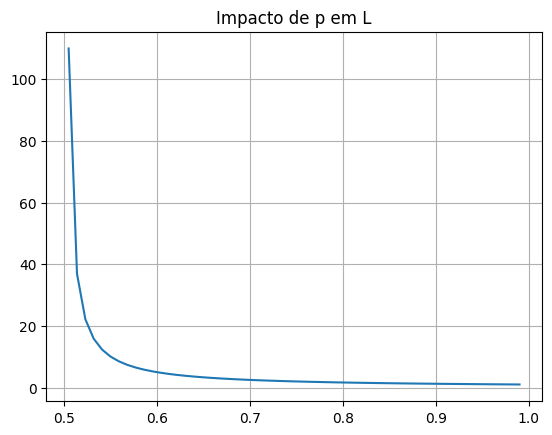

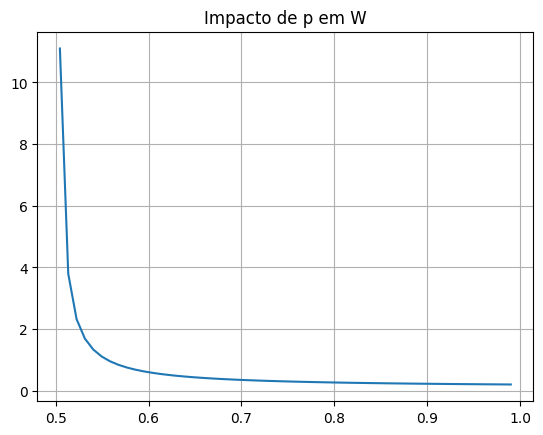

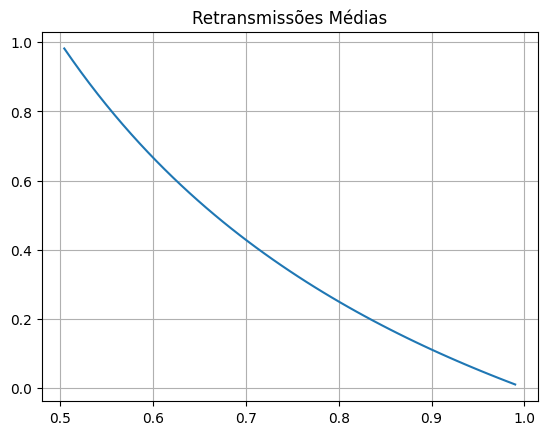

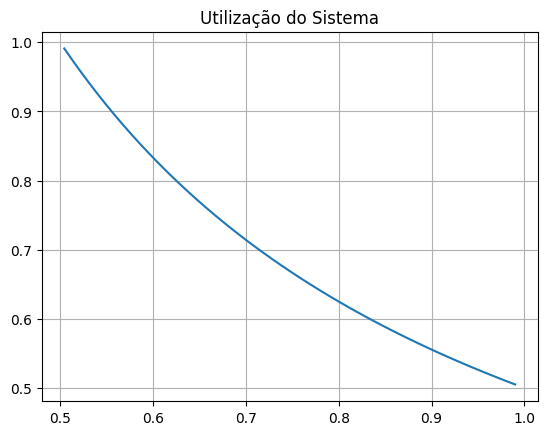

In [14]:
p_values = np.linspace(0.1,0.99,100)

L_values = []
W_values = []
R_values = []
rho_values = []

for p_aux in p_values:

    rho_aux = lambda_rate/(mu*p_aux)

    if rho_aux < 1:

        L_values.append(
            rho_aux/(1-rho_aux)
        )

        W_values.append(
            1/(mu-lambda_rate/p_aux)
        )

        R_values.append(
            (1-p_aux)/p_aux
        )

        rho_values.append(rho_aux)

    else:

        L_values.append(np.nan)
        W_values.append(np.nan)
        R_values.append(np.nan)
        rho_values.append(np.nan)

plt.figure()
plt.plot(p_values,L_values)
plt.title("Impacto de p em L")
plt.grid()
plt.show()

plt.figure()
plt.plot(p_values,W_values)
plt.title("Impacto de p em W")
plt.grid()
plt.show()

plt.figure()
plt.plot(p_values,R_values)
plt.title("Retransmissões Médias")
plt.grid()
plt.show()

plt.figure()
plt.plot(p_values,rho_values)
plt.title("Utilização do Sistema")
plt.grid()
plt.show()